# PINN: Trajektorie lernen → danach Wurf klassifizieren (clean & noisy)




In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
device = "cpu"

device: cpu


In [2]:
class DataGen:
    def __init__(self, hs=2.13, l=4.115, hKorb=3.048, Rr=0.2286, Rb=0.1219, g=9.807):
        self.params = {'l': l, 'hKorb': hKorb, 'Rr': Rr, 'Rb': Rb, 'g': g}
        self.hs = hs
        self.wurf_hoehe = 1.25 * hs
    def wurfgeschwindigkeit(self, theta):
        l = self.params['l']; h = self.params['hKorb'] - self.wurf_hoehe; g = self.params['g']
        return (l/np.cos(theta)) * np.sqrt(g / (2 * (l*np.tan(theta) - h)))
    def wurftrajektorien(self, theta, v0, t):
        g = self.params['g']; vx = v0*np.cos(theta); vy = v0*np.sin(theta)
        x = vx * t; y = vy * t - 0.5 * g * t**2 + self.wurf_hoehe
        return x, y
    def generate_dataset(self, base_theta_deg=48.43, n=150, with_noise=False):
        base_theta = np.deg2rad(base_theta_deg); base_v0 = self.wurfgeschwindigkeit(base_theta)
        cats = {0:{'theta':(-0.15,-0.05),'v0':(-0.5,-0.2)}, 1:{'theta':(-0.03,0.03),'v0':(-0.1,0.1)}, 2:{'theta':(0.06,0.15),'v0':(0.3,0.5)}}
        rows=[]
        for label,var in cats.items():
            rows += self._gen(base_theta, base_v0, var, label, n)
        df = pd.DataFrame(rows)
        if with_noise:
            df = self.full_noise_pipeline(df)
        return df
    def _gen(self, theta_base, v0_base, var, label, n):
        g = self.params['g']; rows=[]
        for _ in range(n):
            theta = theta_base + np.random.uniform(*var['theta'])
            v0 = v0_base + np.random.uniform(*var['v0'])
            T = 2 * v0 * np.sin(theta) / g
            t_vals = np.linspace(0, T, 50)
            x, y = self.wurftrajektorien(theta, v0, t_vals)
            wid = str(np.random.randint(1e9))
            for xi, yi, ti in zip(x, y, t_vals):
                rows.append({'x':xi,'y':yi,'theta':theta,'v0':v0,'t':ti,'label':label,'wurf_id':wid})
        return rows
    def add_position_noise(self, df, std_x=0.1, std_y=0.1):
        d = df.copy(); d['x'] += np.random.normal(0,std_x,len(df)); d['y'] += np.random.normal(0,std_y,len(df)); return d
    def full_noise_pipeline(self, df):
        return self.add_position_noise(df)


In [3]:
class TrajDataset(Dataset):
    def __init__(self, df, n_obs=30, mode="clean", x_scale=4.115, y_scale=3.5):
        """
        mode:
          - "clean": DataLoss auf allen Punkten (typisch 50)
          - "noisy": DataLoss auf allen Punkten, später z.B. Huber verwenden
          - "trimmed": DataLoss nur auf den ersten n_obs Punkten (für Extrapolation)
        """
        self.n_obs = n_obs
        self.mode = mode
        self.x_scale = x_scale
        self.y_scale = y_scale

        self.throws = []
        for wid, g in df.groupby("wurf_id"):
            g = g.sort_values("t")

            t = g["t"].to_numpy()
            x = g["x"].to_numpy()
            y = g["y"].to_numpy()
            label = int(g["label"].iloc[0])

            T = float(t.max())
            s = t / (T + 1e-12)  # normalized time in [0,1]

            x_n = (x / self.x_scale).astype(np.float32)
            y_n = (y / self.y_scale).astype(np.float32)
            s = s.astype(np.float32)

            self.throws.append(
                {
                    "s": s,
                    "x": x_n,
                    "y": y_n,
                    "T": np.float32(T),
                    "label": label,
                    "wurf_id": wid,
                }
            )

    def __len__(self):
        return len(self.throws)

    def __getitem__(self, idx):
        d = self.throws[idx]

        s = torch.from_numpy(d["s"])  # [50]
        x = torch.from_numpy(d["x"])  # [50]
        y = torch.from_numpy(d["y"])  # [50]
        T = torch.tensor(d["T"], dtype=torch.float32)
        label = torch.tensor(d["label"], dtype=torch.long)

        # Encoder input: first n_obs points
        s_obs = s[: self.n_obs]
        x_obs = x[: self.n_obs]
        y_obs = y[: self.n_obs]
        enc_in = torch.stack([s_obs, x_obs, y_obs], dim=-1)  # [n_obs, 3]

        # Targets for data loss
        if self.mode == "trimmed":
            s_tgt, x_tgt, y_tgt = s_obs, x_obs, y_obs
        else:
            s_tgt, x_tgt, y_tgt = s, x, y

        tgt = torch.stack([s_tgt, x_tgt, y_tgt], dim=-1)  # [N_tgt, 3]
        return enc_in, tgt, T, label


def split_by_wurf_id(df, train_ratio=0.8, seed=42):
    rng = np.random.default_rng(seed)
    ids = df["wurf_id"].unique()
    rng.shuffle(ids)
    split = int(train_ratio * len(ids))
    train_ids = set(ids[:split])
    test_ids = set(ids[split:])
    return (
        df[df["wurf_id"].isin(train_ids)].copy(),
        df[df["wurf_id"].isin(test_ids)].copy(),
    )


def make_loaders(
    df_train, df_test, n_obs, train_mode, test_mode, x_scale, y_scale, batch_size=64
):
    train_ds = TrajDataset(
        df_train, n_obs=n_obs, mode=train_mode, x_scale=x_scale, y_scale=y_scale
    )
    test_ds = TrajDataset(
        df_test, n_obs=n_obs, mode=test_mode, x_scale=x_scale, y_scale=y_scale
    )

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True, drop_last=True
    )
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return train_ds, test_ds, train_loader, test_loader


def trim_df_first_n(df, n_obs=30):
    # nimmt pro wurf_id die ersten n_obs Zeilen nach t
    return (
        df.sort_values(["wurf_id", "t"])
        .groupby("wurf_id", as_index=False, group_keys=False)
        .head(n_obs)
        .copy()
    )

In [4]:
class Encoder(nn.Module):
    def __init__(self, n_obs=30, z_dim=16):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(n_obs * 3, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
        )
        self.to_z = nn.Linear(128, z_dim)
        self.to_v = nn.Linear(128, 2)  # vx, vy in m/s

    def forward(self, enc_in):
        h = self.backbone(enc_in.reshape(enc_in.shape[0], -1))
        z = self.to_z(h)
        v = self.to_v(h)
        vx, vy = v[..., 0], v[..., 1]
        return z, vx, vy


class Decoder(nn.Module):
    def __init__(self, z_dim=16, y0_norm=0.76):
        super().__init__()
        self.y0 = float(y0_norm)
        self.net = nn.Sequential(
            nn.Linear(1 + z_dim, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 2)  # fx, fy
        )

    def forward(self, s, z):
        B, N = s.shape
        zz = z.unsqueeze(1).expand(B, N, z.shape[-1])
        inp = torch.cat([s.unsqueeze(-1), zz], dim=-1)  # [B,N,1+z]
        out = self.net(inp)                             # [B,N,2]
        fx, fy = out[..., 0], out[..., 1]

        # hard-ish BC
        x = s * fx
        y = self.y0 + s * fy
        return x, y


class Classifier(nn.Module):
    def __init__(self, z_dim=16, n_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 64),
            nn.ReLU(),
            nn.Linear(64, n_classes)
        )

    def forward(self, z):
        return self.net(z)


class PINNModel(nn.Module):
    def __init__(self, n_obs=30, z_dim=16, y0_norm=0.76, n_classes=3):
        super().__init__()
        self.enc = Encoder(n_obs=n_obs, z_dim=z_dim)
        self.dec = Decoder(z_dim=z_dim, y0_norm=y0_norm)
        self.clf = Classifier(z_dim=z_dim, n_classes=n_classes)

    def forward(self, enc_in, s_query):
        z, vx, vy = self.enc(enc_in)
        x, y = self.dec(s_query, z)
        logits = self.clf(z)
        return x, y, logits, z, vx, vy


In [5]:
def physics_residuals(
    model, enc_in, T, n_col=64, g=9.807, x_scale=4.115, y_scale=3.5, device="cuda"
):
    """
    residuals (in normalized coordinate outputs x*, y*):
      rx = d(x*)/dt - vx/x_scale
      ry = d(y*)/dt - (vy/y_scale - (g/y_scale)*t)
    where t = s*T, and d/dt = (1/T) d/ds
    """
    B = enc_in.shape[0]
    s = torch.rand(B, n_col, device=device, requires_grad=True)
    t = s * T.view(-1, 1)

    z, vx, vy = model.enc(enc_in)
    x, y = model.dec(s, z)

    dx_ds = torch.autograd.grad(x.sum(), s, create_graph=True)[0]
    dy_ds = torch.autograd.grad(y.sum(), s, create_graph=True)[0]

    T_ = T.view(-1, 1) + 1e-12
    dx_dt = dx_ds / T_
    dy_dt = dy_ds / T_

    vx_norm = vx.view(-1, 1) / x_scale
    vy_norm = vy.view(-1, 1) / y_scale
    g_norm = g / y_scale

    rx = dx_dt - vx_norm
    ry = dy_dt - (vy_norm - g_norm * t)
    return rx, ry

In [13]:
def compute_data_loss(x_pred, y_pred, x_true, y_true, mode="clean"):
    if mode == "noisy":
        return F.smooth_l1_loss(x_pred, x_true) + F.smooth_l1_loss(y_pred, y_true)
    return F.mse_loss(x_pred, x_true) + F.mse_loss(y_pred, y_true)


def train_one_epoch(model, loader, opt, cfg):
    model.train()
    agg = {"loss": 0.0, "data": 0.0, "phys": 0.0, "cls": 0.0}
    nb = 0

    for enc_in, tgt, T, label in loader:
        enc_in = enc_in.to(cfg["device"])
        tgt    = tgt.to(cfg["device"])
        T      = T.to(cfg["device"])
        label  = label.to(cfg["device"])

        s_tgt  = tgt[..., 0]
        x_true = tgt[..., 1]
        y_true = tgt[..., 2]

        x_pred, y_pred, logits, *_ = model(enc_in, s_tgt)

        data_loss = compute_data_loss(x_pred, y_pred, x_true, y_true, mode=cfg["train_mode"])

        rx, ry = physics_residuals(
            model, enc_in, T, n_col=cfg["n_col"], g=cfg["g"],
            x_scale=cfg["x_scale"], y_scale=cfg["y_scale"], device=cfg["device"]
        )
        phys_loss = (rx**2).mean() + (ry**2).mean()

        cls_loss = F.cross_entropy(logits, label)

        loss = cfg["lam_data"]*data_loss + cfg["lam_phys"]*phys_loss + cfg["lam_cls"]*cls_loss

        opt.zero_grad()
        loss.backward()
        opt.step()

        agg["loss"] += float(loss.item())
        agg["data"] += float(data_loss.item())
        agg["phys"] += float(phys_loss.item())
        agg["cls"]  += float(cls_loss.item())
        nb += 1

    for k in agg:
        agg[k] /= max(nb, 1)
    return agg


@torch.no_grad()
def predict_one_throw(model, dataset, idx, cfg):
    model.eval()
    enc_in, tgt, T, label = dataset[idx]

    enc_in = enc_in.unsqueeze(0).to(cfg["device"])
    tgt    = tgt.unsqueeze(0).to(cfg["device"])

    s_all  = tgt[..., 0]
    x_gt_n = tgt[..., 1]
    y_gt_n = tgt[..., 2]

    x_pred_n, y_pred_n, logits, *_ = model(enc_in, s_all)

    # de-normalize
    x_gt = (x_gt_n.squeeze(0).cpu().numpy()) * cfg["x_scale"]
    y_gt = (y_gt_n.squeeze(0).cpu().numpy()) * cfg["y_scale"]
    x_pr = (x_pred_n.squeeze(0).cpu().numpy()) * cfg["x_scale"]
    y_pr = (y_pred_n.squeeze(0).cpu().numpy()) * cfg["y_scale"]

    y_true = int(label.item())
    y_pred = int(torch.argmax(logits, dim=-1).item())

    return x_gt, y_gt, x_pr, y_pr, y_true, y_pred


@torch.no_grad()
def eval_confusion_matrix(model, loader, cfg, n_classes=3):
    model.eval()
    ys, ps = [], []
    for enc_in, tgt, T, label in loader:
        enc_in = enc_in.to(cfg["device"])
        label  = label.to(cfg["device"])

        z, vx, vy = model.enc(enc_in)
        logits = model.clf(z)
        pred = torch.argmax(logits, dim=-1)

        ys.append(label.cpu().numpy())
        ps.append(pred.cpu().numpy())

    y_true = np.concatenate(ys)
    y_pred = np.concatenate(ps)
    cm = confusion_matrix(y_true, y_pred, labels=list(range(n_classes)))
    return cm


def plot_losses(hist):
    plt.figure()
    plt.plot([h["loss"] for h in hist], label="total")
    plt.plot([h["data"] for h in hist], label="data")
    plt.plot([h["phys"] for h in hist], label="phys")
    plt.plot([h["cls"]  for h in hist], label="cls")
    plt.yscale("log")
    plt.xlabel("epoch")
    plt.ylabel("loss (log)")
    plt.title("Training Loss")
    plt.legend()
    plt.show()


def plot_trajectory(x_gt, y_gt, x_pr, y_pr, title="Trajectory: Pred vs GT"):
    plt.figure()
    plt.plot(x_gt, y_gt, marker="o", linewidth=2, label="GT")
    plt.plot(x_pr, y_pr, marker="x", linewidth=2, label="Pred")
    plt.xlabel("x [m]")
    plt.ylabel("y [m]")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_confusion(cm, labels=(0,1,2), title="Confusion Matrix"):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(labels))
    disp.plot(values_format="d")
    plt.title(title)
    plt.show()


## Clean‑Training (Trajektorie) → Wurfklassifikation aus Vorhersage

n_train_throws: 360 n_test_throws: 90
Epoch    1 | loss=2.4139e+00 data=5.1623e-01 phys=1.7878e+00 cls=1.0983e+00
Epoch   20 | loss=1.9669e-01 data=1.0045e-02 phys=7.7173e-02 cls=1.0947e+00
Epoch   40 | loss=1.5749e-01 data=1.2232e-02 phys=4.6643e-02 cls=9.8620e-01
Epoch   60 | loss=7.2225e-02 data=8.2891e-03 phys=3.1526e-02 cls=3.2410e-01
Epoch   80 | loss=4.7162e-03 data=8.2193e-04 phys=1.3727e-03 cls=2.5216e-02
Epoch  100 | loss=2.5578e-03 data=5.4420e-04 phys=9.7776e-04 cls=1.0358e-02
Epoch  120 | loss=1.5582e-03 data=3.1478e-04 phys=6.7601e-04 cls=5.6738e-03
Epoch  140 | loss=1.2701e-03 data=2.7960e-04 phys=6.9977e-04 cls=2.9072e-03
Epoch  160 | loss=1.1101e-03 data=2.6267e-04 phys=6.0553e-04 cls=2.4191e-03
Epoch  180 | loss=8.7677e-04 data=2.3437e-04 phys=4.6556e-04 cls=1.7685e-03
Epoch  200 | loss=9.4376e-04 data=2.5255e-04 phys=5.6470e-04 cls=1.2651e-03


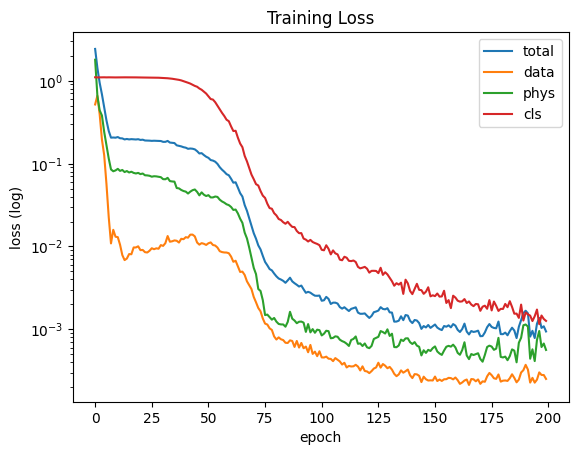

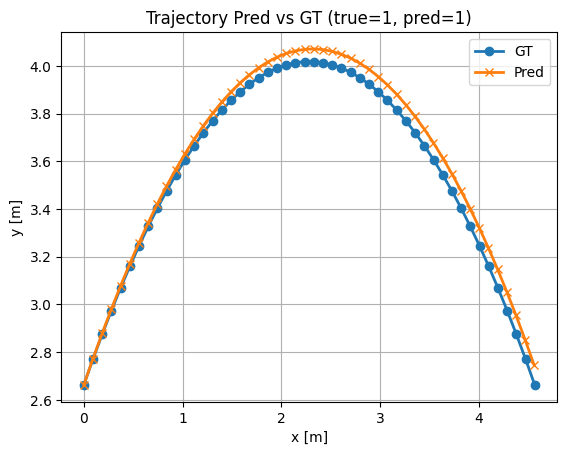

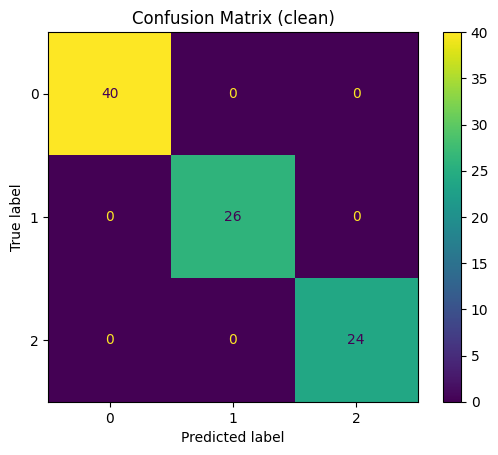

In [14]:
dg = DataGen()
df_clean = dg.generate_dataset(with_noise=False)

# split
df_train, df_test = split_by_wurf_id(df_clean, train_ratio=0.8, seed=42)

# config (hier schraubst du am liebsten)
cfg = {
    "device": device,
    "train_mode": "clean",
    "test_mode": "clean",
    "n_obs": 30,
    "batch_size": 64,
    "epochs": 200,
    "lr": 1e-3,
    "lam_data": 1.0,
    "lam_phys": 1.0,
    "lam_cls": 0.1,
    "n_col": 64,
    "g": dg.params["g"],
    "x_scale": dg.params["l"],
    "y_scale": 3.5,
}
cfg["y0_norm"] = dg.wurf_hoehe / cfg["y_scale"]

# loaders
train_ds, test_ds, train_loader, test_loader = make_loaders(
    df_train,
    df_test,
    n_obs=cfg["n_obs"],
    train_mode=cfg["train_mode"],
    test_mode=cfg["test_mode"],
    x_scale=cfg["x_scale"],
    y_scale=cfg["y_scale"],
    batch_size=cfg["batch_size"],
)

print("n_train_throws:", len(train_ds), "n_test_throws:", len(test_ds))

# model + optimizer
model = PINNModel(n_obs=cfg["n_obs"], z_dim=16, y0_norm=cfg["y0_norm"], n_classes=3).to(
    cfg["device"]
)
opt = torch.optim.Adam(model.parameters(), lr=cfg["lr"])

# train
hist = []
for ep in range(1, cfg["epochs"] + 1):
    metrics = train_one_epoch(model, train_loader, opt, cfg)
    hist.append(metrics)

    if ep % 20 == 0 or ep == 1:
        print(
            f"Epoch {ep:4d} | "
            f"loss={metrics['loss']:.4e} data={metrics['data']:.4e} phys={metrics['phys']:.4e} cls={metrics['cls']:.4e}"
        )

# plots
plot_losses(hist)

# trajectory plot (test sample idx=0, kannst du ändern)
x_gt, y_gt, x_pr, y_pr, y_true, y_pred = predict_one_throw(
    model, test_ds, idx=0, cfg=cfg
)
plot_trajectory(
    x_gt,
    y_gt,
    x_pr,
    y_pr,
    title=f"Trajectory Pred vs GT (true={y_true}, pred={y_pred})",
)

# confusion matrix
cm = eval_confusion_matrix(model, test_loader, cfg, n_classes=3)
plot_confusion(cm, labels=(0, 1, 2), title="Confusion Matrix (clean)")

## Noisy‑Training (Trajektorie) → Wurfklassifikation aus Vorhersage

n_train_throws: 360 n_test_throws: 90
Epoch    1 | loss=2.0401e+00 data=3.0338e-01 phys=1.6270e+00 cls=1.0979e+00
Epoch   20 | loss=1.9192e-01 data=6.9467e-03 phys=7.5615e-02 cls=1.0936e+00
Epoch   40 | loss=1.6518e-01 data=8.3160e-03 phys=5.1032e-02 cls=1.0583e+00
Epoch   60 | loss=1.0531e-01 data=7.3434e-03 phys=4.1721e-02 cls=5.6247e-01
Epoch   80 | loss=1.5002e-02 data=2.0195e-03 phys=6.1248e-03 cls=6.8581e-02
Epoch  100 | loss=6.5859e-03 data=1.3878e-03 phys=3.4040e-03 cls=1.7941e-02
Epoch  120 | loss=3.6103e-03 data=1.1189e-03 phys=1.6675e-03 cls=8.2395e-03
Epoch  140 | loss=3.3132e-03 data=1.0066e-03 phys=1.6746e-03 cls=6.3207e-03
Epoch  160 | loss=2.9191e-03 data=9.5523e-04 phys=1.5523e-03 cls=4.1156e-03
Epoch  180 | loss=2.4730e-03 data=8.9390e-04 phys=1.3068e-03 cls=2.7234e-03
Epoch  200 | loss=2.4357e-03 data=8.5298e-04 phys=1.3931e-03 cls=1.8960e-03


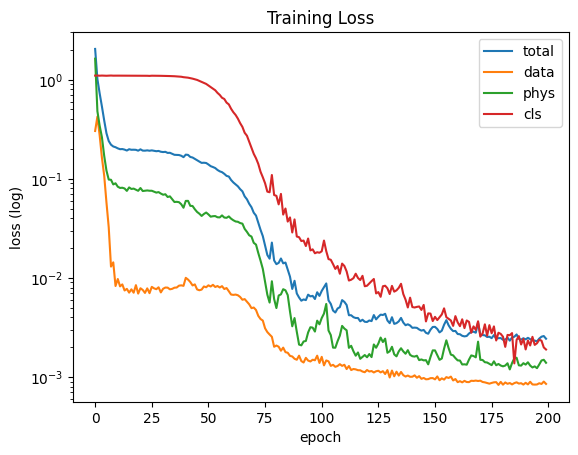

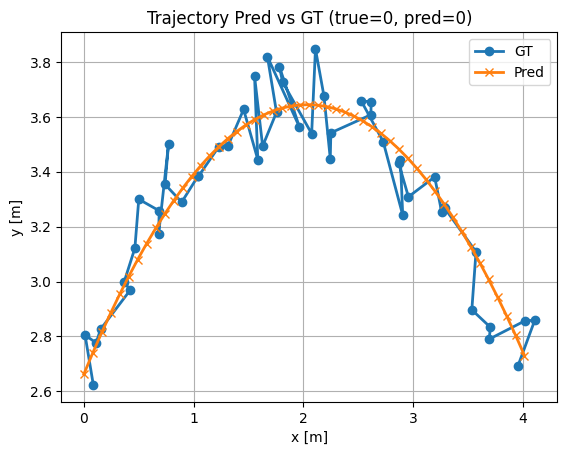

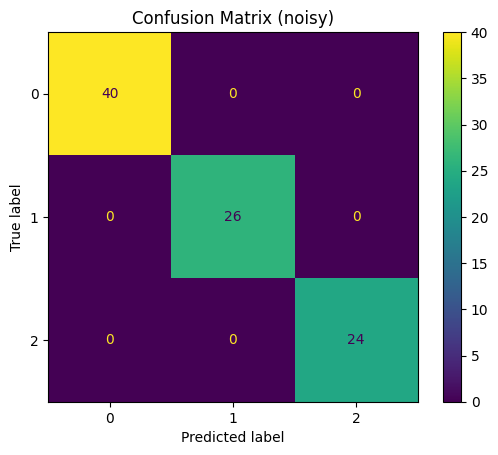

In [23]:
df_noisy = dg.generate_dataset(with_noise=True)

# split
df_train_noisy, df_test_noisy = split_by_wurf_id(df_noisy, train_ratio=0.8, seed=42)

# config (hier schraubst du am liebsten)
cfg = {
    "device": device,
    "train_mode": "noisy",
    "test_mode": "noisy",
    "n_obs": 30,
    "batch_size": 64,
    "epochs": 200,
    "lr": 1e-3,
    "lam_data": 1.0,
    "lam_phys": 1.0,
    "lam_cls": 0.1,
    "n_col": 64,
    "g": dg.params["g"],
    "x_scale": dg.params["l"],
    "y_scale": 3.5,
}
cfg["y0_norm"] = dg.wurf_hoehe / cfg["y_scale"]

# loaders
train_ds_noisy, test_ds_noisy, train_loader_noisy, test_loader_noisy = make_loaders(
    df_train_noisy,
    df_test_noisy,
    n_obs=cfg["n_obs"],
    train_mode=cfg["train_mode"],
    test_mode=cfg["test_mode"],
    x_scale=cfg["x_scale"],
    y_scale=cfg["y_scale"],
    batch_size=cfg["batch_size"],
)

print("n_train_throws:", len(train_ds_noisy), "n_test_throws:", len(test_ds_noisy))

# model + optimizer
model_noisy = PINNModel(n_obs=cfg["n_obs"], z_dim=16, y0_norm=cfg["y0_norm"], n_classes=3).to(
    cfg["device"]
)
opt_noisy = torch.optim.Adam(model_noisy.parameters(), lr=cfg["lr"])

# train
hist_noisy = []
for ep in range(1, cfg["epochs"] + 1):
    metrics_noisy = train_one_epoch(model_noisy, train_loader_noisy, opt_noisy, cfg)
    hist_noisy.append(metrics_noisy)

    if ep % 20 == 0 or ep == 1:
        print(
            f"Epoch {ep:4d} | "
            f"loss={metrics_noisy['loss']:.4e} data={metrics_noisy['data']:.4e} phys={metrics_noisy['phys']:.4e} cls={metrics_noisy['cls']:.4e}"
        )

# plots
plot_losses(hist_noisy)

# trajectory plot (test sample idx=0, kannst du ändern)
x_gt_n, y_gt_n, x_pr_n, y_pr_n, y_true_n, y_pred_n = predict_one_throw(
    model_noisy, test_ds_noisy, idx=0, cfg=cfg
)
plot_trajectory(
    x_gt_n,
    y_gt_n,
    x_pr_n,
    y_pr_n,
    title=f"Trajectory Pred vs GT (true={y_true_n}, pred={y_pred_n})",
)

# confusion matrix
cm_noisy = eval_confusion_matrix(model_noisy, test_loader_noisy, cfg, n_classes=3)
plot_confusion(cm_noisy, labels=(0, 1, 2), title="Confusion Matrix (noisy)")

## Trimmed‑Training (Trajektorie) → Wurfklassifikation aus Vorhersage

n_train_throws: 360 n_test_throws: 90
Epoch    1 | loss=1.9039e+00 data=2.9379e-01 phys=1.4996e+00 cls=1.1050e+00
Epoch   20 | loss=1.9214e-01 data=9.4912e-03 phys=7.3170e-02 cls=1.0948e+00
Epoch   40 | loss=1.6598e-01 data=9.5885e-03 phys=4.9668e-02 cls=1.0673e+00
Epoch   60 | loss=1.0896e-01 data=9.1168e-03 phys=3.8346e-02 cls=6.1502e-01
Epoch   80 | loss=6.6664e-03 data=9.0920e-04 phys=1.1704e-03 cls=4.5868e-02
Epoch  100 | loss=2.4253e-03 data=4.5359e-04 phys=8.0330e-04 cls=1.1684e-02
Epoch  120 | loss=1.5377e-03 data=3.3678e-04 phys=6.5514e-04 cls=5.4577e-03
Epoch  140 | loss=1.7674e-03 data=2.6813e-04 phys=1.1267e-03 cls=3.7253e-03
Epoch  160 | loss=1.0271e-03 data=1.7871e-04 phys=6.0205e-04 cls=2.4633e-03
Epoch  180 | loss=1.0062e-03 data=1.6543e-04 phys=6.7383e-04 cls=1.6694e-03
Epoch  200 | loss=6.1869e-04 data=1.1550e-04 phys=3.8176e-04 cls=1.2144e-03


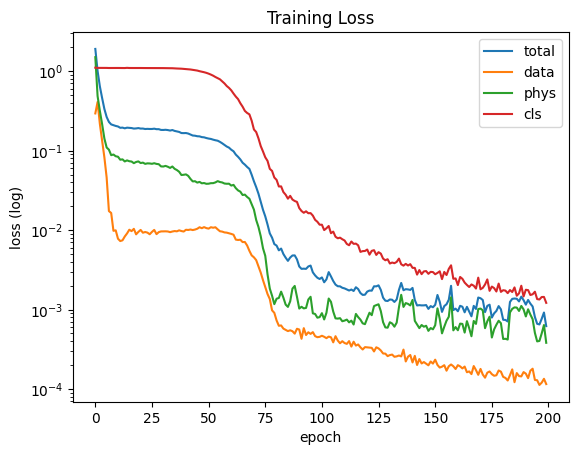

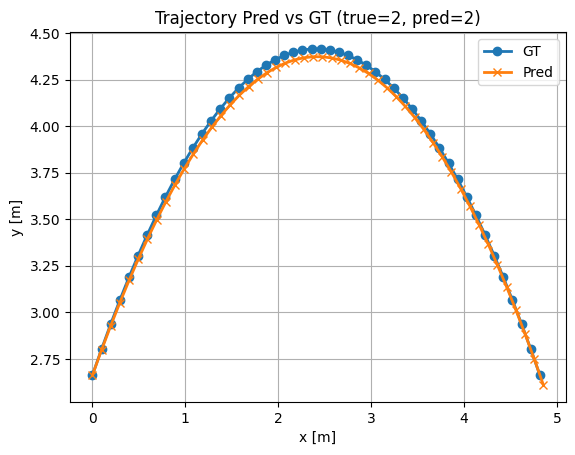

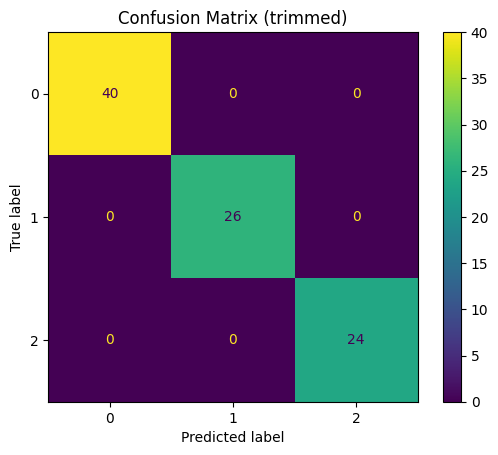

In [21]:
dg = DataGen()
df_clean2 = dg.generate_dataset(with_noise=False)

df_train_full, df_test_full = split_by_wurf_id(df_clean2, train_ratio=0.8, seed=42)

# config (hier schraubst du am liebsten)
cfg = {
    "device": device,
    "train_mode": "trimmed",
    "test_mode": "clean",
    "n_obs": 30,
    "batch_size": 64,
    "epochs": 200,
    "lr": 1e-3,
    "lam_data": 1.0,
    "lam_phys": 1.0,
    "lam_cls": 0.1,
    "n_col": 64,
    "g": dg.params["g"],
    "x_scale": dg.params["l"],
    "y_scale": 3.5,
}
cfg["y0_norm"] = dg.wurf_hoehe / cfg["y_scale"]

# loaders
train_ds_t, test_ds_t, train_loader_t, test_loader_t = make_loaders(
    df_train_full,
    df_test_full,
    n_obs=cfg["n_obs"],
    train_mode=cfg["train_mode"],
    test_mode=cfg["test_mode"],
    x_scale=cfg["x_scale"],
    y_scale=cfg["y_scale"],
    batch_size=cfg["batch_size"],
)


print("n_train_throws:", len(train_ds_t), "n_test_throws:", len(test_ds_t))

# model + optimizer
model_t = PINNModel(n_obs=cfg["n_obs"], z_dim=16, y0_norm=cfg["y0_norm"], n_classes=3).to(
    cfg["device"]
)
opt_t = torch.optim.Adam(model_t.parameters(), lr=cfg["lr"])

# train
hist_t = []
for ep in range(1, cfg["epochs"] + 1):
    metrics_t = train_one_epoch(model_t, train_loader_t, opt_t, cfg)
    hist_t.append(metrics_t)

    if ep % 20 == 0 or ep == 1:
        print(
            f"Epoch {ep:4d} | "
            f"loss={metrics_t['loss']:.4e} data={metrics_t['data']:.4e} phys={metrics_t['phys']:.4e} cls={metrics_t['cls']:.4e}"
        )

# plots
plot_losses(hist_t)

# trajectory plot (test sample idx=0, kannst du ändern)
x_gt_t, y_gt_t, x_pr_t, y_pr_t, y_true_t, y_pred_t = predict_one_throw(
    model_t, test_ds_t, idx=0, cfg=cfg
)
plot_trajectory(
    x_gt_t,
    y_gt_t,
    x_pr_t,
    y_pr_t,
    title=f"Trajectory Pred vs GT (true={y_true_t}, pred={y_pred_t})",
)

# confusion matrix
cm_t = eval_confusion_matrix(model_t, test_loader_t, cfg, n_classes=3)
plot_confusion(cm_t, labels=(0, 1, 2), title="Confusion Matrix (trimmed)")